# Micrograd From Scratch

## 1. Imports

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## 2. Intuition about derivatives

In [2]:
def f(x):
  return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

In [4]:
xs = np.arange(-5, 5, 0.25)
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [5]:
ys = f(xs) # function is applied on each element
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

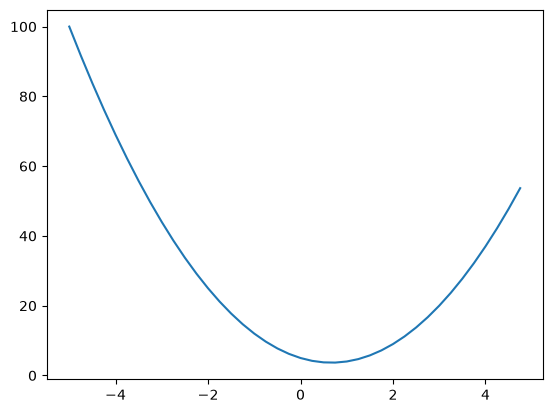

In [6]:
plt.plot(xs, ys)

In [7]:
# when looking at derivation we are trying to find
# how the y changes based on addign small increment to x
h = 0.001
x = 3.0
f(x + h)

20.014003000000002

In [8]:
(f(x + h) - f(x)) / h

14.00300000000243

In [9]:
h = 0.00001
x = -3.0
(f(x + h) - f(x))/h

-21.999970000052823

In [10]:
a = 2.0
b = -3.0
c = 10
d = a * b + c
print(d)

4.0


In [11]:
h = 0.00001

a = 2.0
b = -3.0
c = 10.0
d1 = a * b + c

a += h
d2 = a * b + c
print("d1", d1)
print("d2", d2)
print("slope", (d2-d1)/h)

d1 4.0
d2 3.9999699999999994
slope -3.000000000064062


In [12]:
h = 0.00001

a = 2.0
b = -3.0
c = 10.0
d1 = a * b + c

b += h
d2 = a * b + c
print("d1", d1)
print("d2", d2)
print("slope", (d2-d1)/h)

d1 4.0
d2 4.00002
slope 2.0000000000131024


In [13]:
h = 0.00001

a = 2.0
b = -3.0
c = 10.0
d1 = a * b + c

c += h
d2 = a * b + c
print("d1", d1)
print("d2", d2)
print("slope", (d2-d1)/h)

d1 4.0
d2 4.00001
slope 0.9999999999621422


## 3. Building out Value Class

In [14]:
class Value:
  def __init__(self, data):
    self.data = data

  def __repr__(self):
    return f"Value(data={self.data})"

a = Value(2.0)
a

Value(data=2.0)

In [15]:
a = Value(2.0)
b = Value(-3.0)
a + b # calls a.__add__(b)

TypeError: unsupported operand type(s) for +: 'Value' and 'Value'

In [16]:
class Value:
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    return Value(self.data + other.data, (self, other), _op="+")

  def __mul__(self, other):
    return Value(self.data * other.data, (self, other), "*")

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label = 'e'
d = c + e; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

In [17]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [18]:
d._op

'+'

In [19]:
d.label

'd'

## 4. Manual Backpropagation

In [20]:
from graphviz import Digraph

def trace(root):
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges


def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    dot.node(name=uid, label="{%s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      dot.node(name=uid + n._op, label=n._op)
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

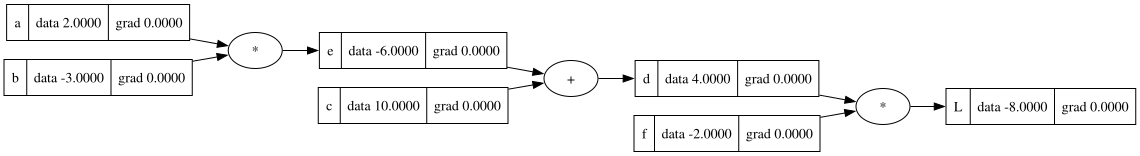

In [21]:
draw_dot(L)

In [22]:
L.grad = 1.0

# L = d * f
#
# dL/dd = ? -> f

f.grad = d.data
d.grad = f.data

# dL/dc = ?
#
# chain rule -> dL/dc = dL/dd * dd/dc

c.grad = d.grad * 1.0
e.grad = d.grad * 1.0

# dL/db = ?
#
# chain rule -> dL/da = dL/de * de/da

a.grad = e.grad * b.data
b.grad = e.grad * a.data

In [23]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f
L

Value(data=-7.286496)

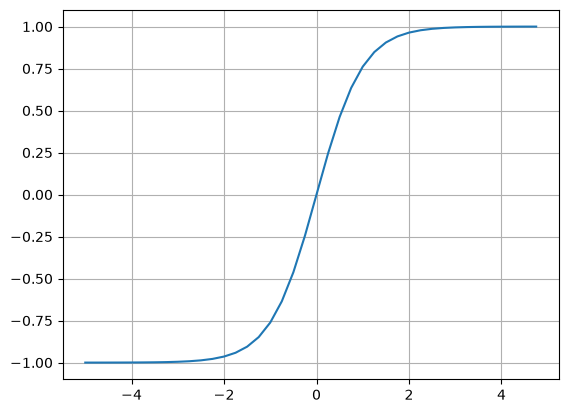

In [24]:
plt.plot(np.arange(-5, 5, 0.25), np.tanh(np.arange(-5, 5, 0.25)))
plt.grid()

In [25]:
class Value:
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    return Value(self.data + other.data, (self, other), _op="+")

  def __mul__(self, other):
    return Value(self.data * other.data, (self, other), "*")

  def __pow__(self, other):
    return Value(self.data ** other.data, (self, other), "**")

  def tanh(self):
    return Value((math.exp(2*self.data) - 1) / (math.exp(2*self.data) + 1), (self,), "tanh")

In [26]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')

x1w1 = w1 * x1; x1w1.label = 'x1w1'
x2w2 = w2 * x2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = "o"

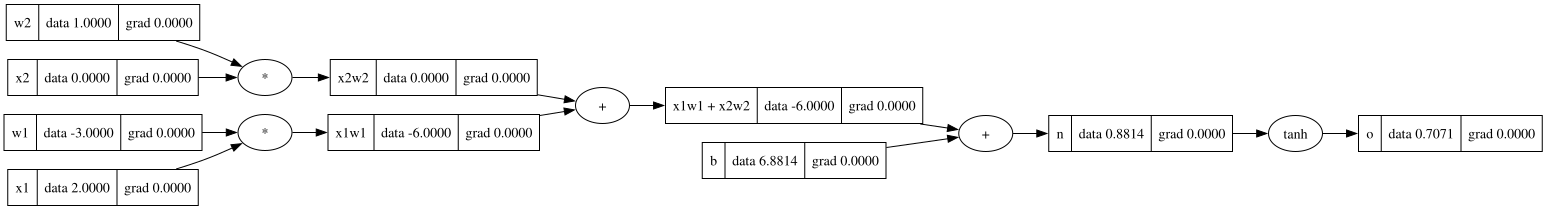

In [27]:
draw_dot(o)

In [28]:
o.grad = 1.0

# do/dn -> ?
#
# do/dn = 1 - tanh(x)**2
n.grad = 1 - o.data**2

# do/db = ?
#
# chain rule -> do/dn * dn/db
b.grad = n.grad
x1w1x2w2.grad = n.grad

x1w1.grad = x1w1x2w2.grad
x2w2.grad = x1w1x2w2.grad

w1.grad = x1w1.grad * x1.data
x1.grad = x1w1.grad * w1.data

w2.grad = x2w2.grad * x2.data
x2.grad = x2w2.grad * w2.data

## 5. Automating Backpropagation

In [29]:
class Value:
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), _op="+")

    def _backward():
      self.grad = 1.0 * out.grad
      other.grad = 1.0 * out.grad

    out._backward = _backward
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), _op="*")

    def _backward():
      self.grad = other.data * out.grad
      other.grad = self.data * out.grad

    out._backward = _backward
    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
    out = Value(t, (self,), "tanh")

    def _backward():
      self.grad = (1 - t**2) * out.grad

    out._backward = _backward
    return out

In [30]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')

x1w1 = w1 * x1; x1w1.label = 'x1w1'
x2w2 = w2 * x2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = "o"

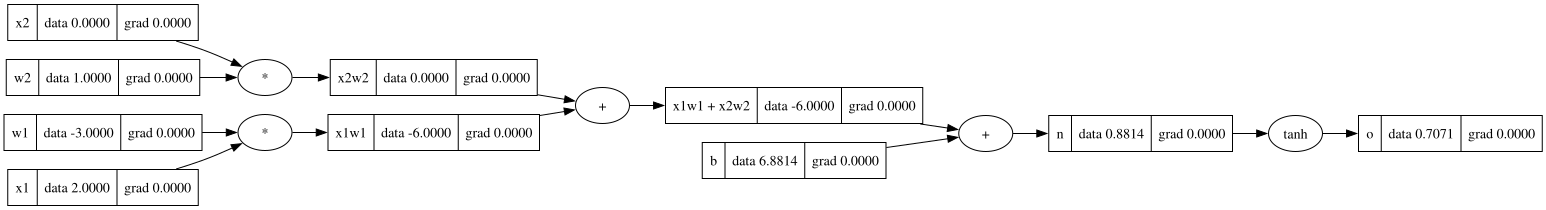

In [31]:
draw_dot(o)

In [32]:
o.grad = 1.0
o._backward()

In [33]:
n._backward()

In [34]:
b._backward()

In [35]:
x1w1x2w2._backward()

In [36]:
x1w1._backward()
x2w2._backward()

In [37]:
# Topological Sort
#
# We are using topological sort L->R as we want to get graph elements from left to right inside a list
# and each element only comes after its inputs
# That way we can automate backpropagation
topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)

build_topo(o)
topo

[Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [38]:
class Value:
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), _op="+")

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad

    out._backward = _backward
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), _op="*")

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad

    out._backward = _backward
    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
    out = Value(t, (self,), "tanh")

    def _backward():
      self.grad += (1 - t**2) * out.grad

    out._backward = _backward
    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

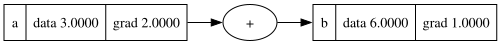

In [39]:
a = Value(data=3.0, label='a')
b = a + a; b.label='b'
b.backward()
draw_dot(b)

## 6. Expanding Value Class

In [40]:
a = Value(3.0)
a + 1

AttributeError: 'int' object has no attribute 'data'

In [41]:
class Value:
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), _op="+")

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad

    out._backward = _backward
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), _op="*")

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad

    out._backward = _backward
    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f"**{other}")

    def _backward():
      self.grad = other * (self.data ** (other - 1)) * out.grad

    out._backward = _backward
    return out

  def __rmul__(self, other):
    return self * other

  def __truediv__(self, other):
    return self * other**-1

  def __neg__(self):
    return self * -1

  def __sub__(self, other):
    return self + (-other)

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
    out = Value(t, (self,), "tanh")

    def _backward():
      self.grad += (1 - t**2) * out.grad

    out._backward = _backward
    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), "exp")

    def _backward():
      self.grad += out.data * out.grad

    out._backward = _backward
    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

In [42]:
a = Value(3.0)
a + 1

Value(data=4.0)

In [43]:
a = Value(3.0)
a * 1

Value(data=3.0)

In [44]:
2 * a

Value(data=6.0)

In [45]:
a = Value(3.0)
a.exp()

Value(data=20.085536923187668)

In [46]:
a = Value(2.0)
b = Value(4.0)
a / b

Value(data=0.5)

In [47]:
a - b

Value(data=-2.0)

In [48]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')

x1w1 = w1 * x1; x1w1.label = 'x1w1'
x2w2 = w2 * x2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = "o"
o.backward()

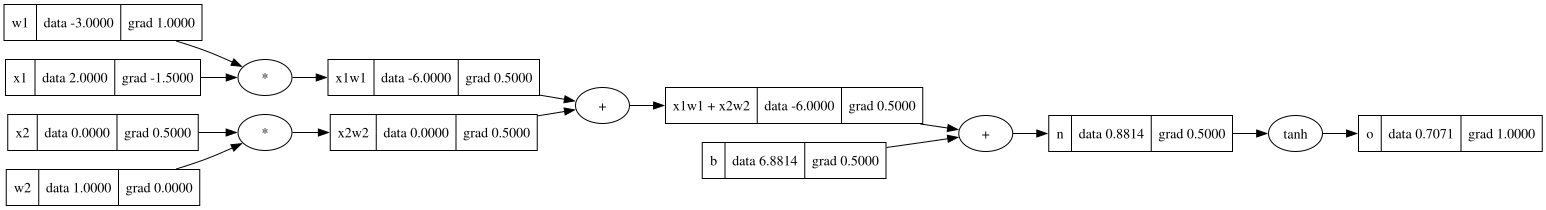

In [49]:
draw_dot(o)

In [50]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')

x1w1 = w1 * x1; x1w1.label = 'x1w1'
x2w2 = w2 * x2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'

e = (2*n).exp(); e.label = 'e'
o = (e - 1) / (e + 1); o.label = 'o'
o.backward()

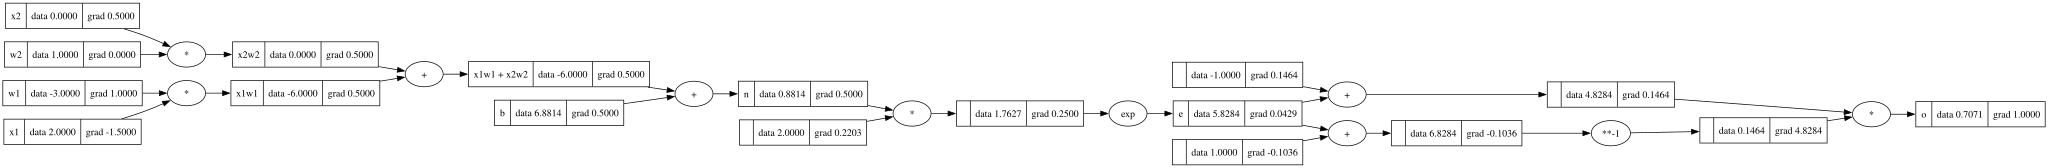

In [51]:
draw_dot(o)

## 7. Doing Backpropagation in PyTorch

In [52]:
import torch

x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True
n = w1 * x1 + w2 * x2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('x1', x1.grad.item())
print('w2', w2.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
x1 -1.5000003851533106
w2 0.0
w1 1.0000002567688737
